Load Data

In [ ]:
import os

PATH_ZIP = "/content/drive/MyDrive/Computervison/data.zip"
!unzip -q "{PATH_ZIP}" -d "/content/"

# Cari otomatis folder train dan validation/val di mana pun lokasinya
train_dir = None
test_dir = None

for root, dirs, files in os.walk("/content/data"):
    for d in dirs:
        if d.lower() == "train":
            train_dir = os.path.join(root, d)
        if d.lower() in ["validation", "val", "valid"]:
            test_dir = os.path.join(root, d)

if train_dir is None or test_dir is None:
    print("❌ Folder train/validation tidak ditemukan. Struktur folder hasil ekstrak:")
    for root, dirs, files in os.walk("/content/data"):
        print(root)
else:
    print("✅ Data siap!")
    print("train_dir:", train_dir)
    print("test_dir :", test_dir)
    print("Kategori train:", os.listdir(train_dir))
    print("Kategori val  :", os.listdir(test_dir))

replace /content/data/train/Acral_Lentiginous_Melanoma/1124-Subungual_Melanoma-642x361-slide3_jpg.rf.0dac8bb63db59e791970223a68db4b3e.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
✅ Data siap!
train_dir: /content/data/train
test_dir : /content/data/validation
Kategori train: ['Acral_Lentiginous_Melanoma', 'blue_finger', 'Onychogryphosis', 'clubbing', 'Healthy_Nail', 'pitting']
Kategori val  : ['Acral_Lentiginous_Melanoma', 'blue_finger', 'Onychogryphosis', 'clubbing', 'Healthy_Nail', 'pitting']


import library

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

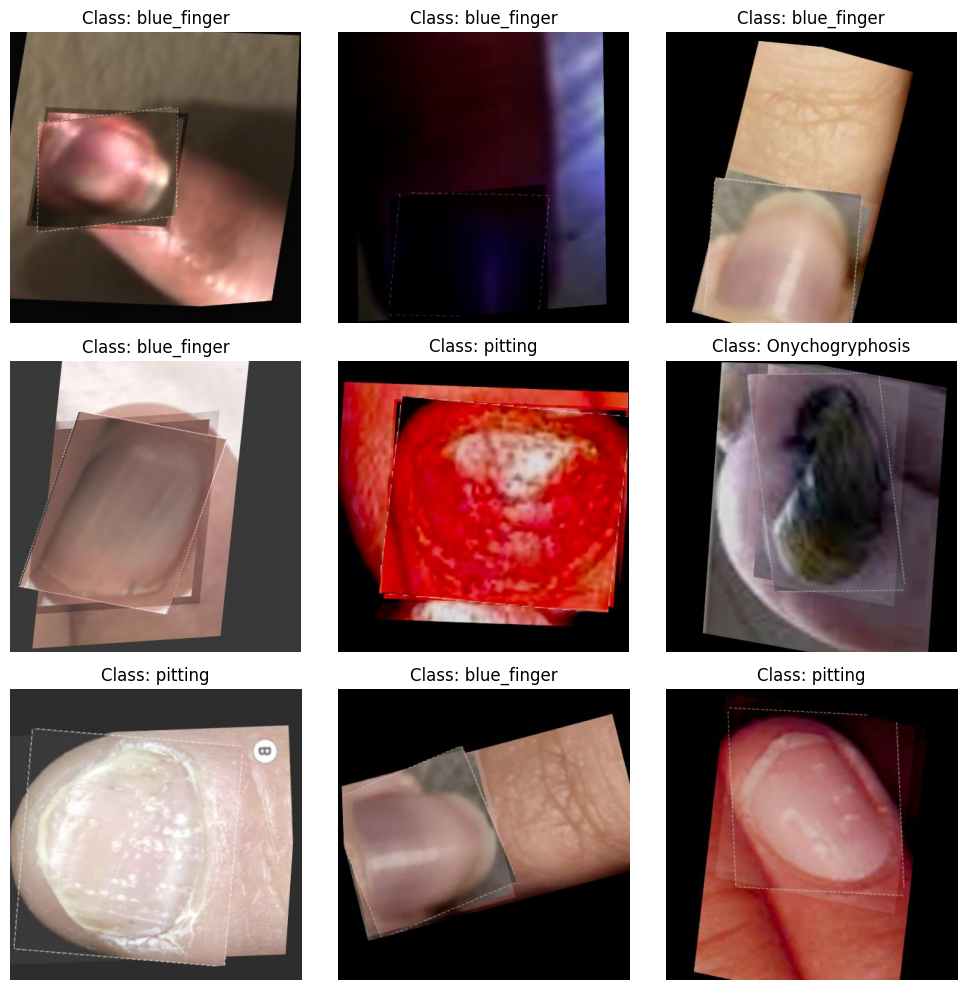

In [ ]:
import random

class_names = sorted(os.listdir(train_dir))

def show_sample_images(dataset_path, class_names, n=9):
    plt.figure(figsize=(10,10))
    for i in range(n):
        class_name = random.choice(class_names)
        class_path = os.path.join(dataset_path, class_name)
        img_name = random.choice(os.listdir(class_path))
        img_path = os.path.join(class_path, img_name)
        img = plt.imread(img_path)
        plt.subplot(3,3,i+1)
        plt.imshow(img)
        plt.title(f"Class: {class_name}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_sample_images(train_dir, class_names)

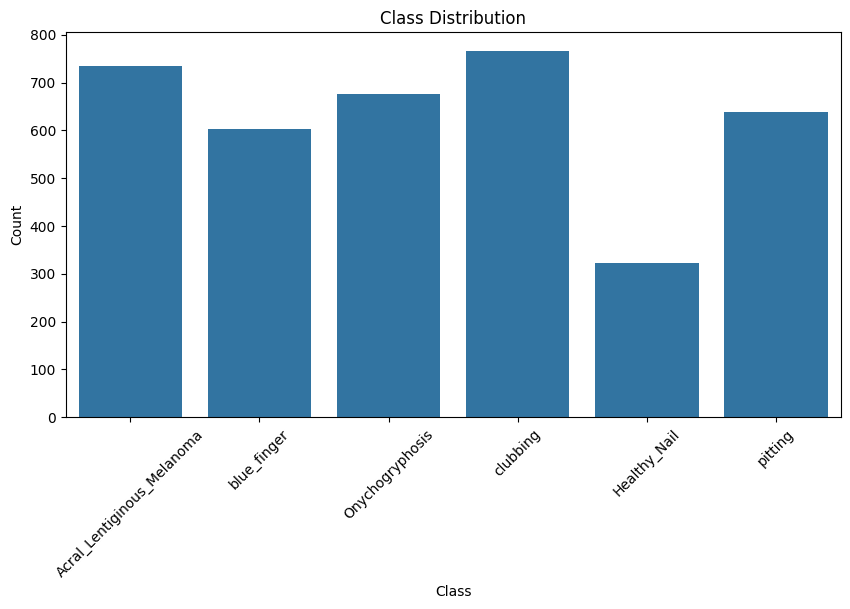

In [ ]:
class_counts = {}
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    class_counts[class_name] = len(os.listdir(class_path))

df = pd.DataFrame(list(class_counts.items()), columns=["Class","Count"])

plt.figure(figsize=(10,5))
sns.barplot(x="Class", y="Count", data=df)
plt.title("Class Distribution")
plt.xticks(rotation=45)
plt.show()

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input,
    validation_split = 0.2,
    zoom_range = 0.15,
    rotation_range = 10,
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    fill_mode = 'nearest'
)

test_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input
)

In [ ]:
train = train_datagen.flow_from_directory(
    train_dir,
    target_size = (260,260),
    class_mode = 'categorical',
    batch_size = 32,
    seed = 42,
    subset = 'training',
    shuffle = True
)

valid = train_datagen.flow_from_directory(
    train_dir,
    target_size = (260,260),
    class_mode = 'categorical',
    batch_size = 32,
    seed = 42,
    subset = 'validation',
    shuffle = False
)

test = test_datagen.flow_from_directory(
    test_dir,
    target_size = (260,260),
    class_mode = 'categorical',
    batch_size = 32,
    seed = 42,
    shuffle = False
)

Found 2998 images belonging to 6 classes.
Found 746 images belonging to 6 classes.
Found 91 images belonging to 6 classes.


In [ ]:
from keras.applications import EfficientNetB2

base = EfficientNetB2(
    weights = 'imagenet',
    include_top = False,
    input_shape = (260,260,3)
)

base.trainable = False

31790344/31790344 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
from keras.models import Sequential
from keras.layers import Dense, GlobalAveragePooling2D, Dropout

Model = Sequential()
Model.add(base)
Model.add(GlobalAveragePooling2D())
Model.add(Dense(256,activation='relu'))
Model.add(Dropout(0.3))
Model.add(Dense(len(class_names),activation='softmax'))

In [ ]:
from keras.optimizers import AdamW

Model.compile(
    optimizer=AdamW(learning_rate=1e-5,weight_decay=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

EarlyStop = EarlyStopping(monitor='val_loss', patience=5)
ReduceLR = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)

In [ ]:
Model.fit(train, validation_data=valid, epochs=50, callbacks=[EarlyStop,ReduceLR])

Epoch 1/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 205s 2s/step - accuracy: 0.2518 - loss: 1.7518 - val_accuracy: 0.3472 - val_loss: 1.6292 - learning_rate: 1.0000e-05
Epoch 2/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 80s 849ms/step - accuracy: 0.3732 - loss: 1.5904 - val_accuracy: 0.5000 - val_loss: 1.4939 - learning_rate: 1.0000e-05
Epoch 3/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 73s 778ms/step - accuracy: 0.4516 - loss: 1.4728 - val_accuracy: 0.5804 - val_loss: 1.3869 - learning_rate: 1.0000e-05
Epoch 4/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 78s 832ms/step - accuracy: 0.5350 - loss: 1.3649 - val_accuracy: 0.6260 - val_loss: 1.2927 - learning_rate: 1.0000e-05
Epoch 5/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 72s 772ms/step - accuracy: 0.5684 - loss: 1.2789 - val_accuracy: 0.6689 - val_loss: 1.2093 - learning_rate: 1.0000e-05
Epoch 6/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 73s 781ms/step - accuracy: 0.5977 - loss: 1.2024 - val_accuracy: 0.6823 - val_loss: 1.1395 - learning_rate: 1.0000e-05
Epoch 7/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 73s 778ms/step - accur

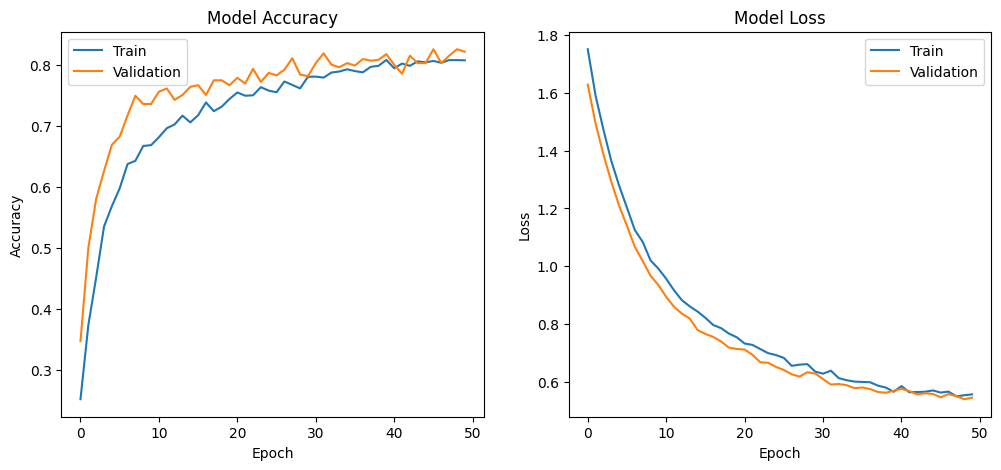

In [ ]:
History = pd.DataFrame(Model.history.history)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(History["accuracy"])
plt.plot(History["val_accuracy"])
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Train","Validation"])

plt.subplot(1,2,2)
plt.plot(History["loss"])
plt.plot(History["val_loss"])
plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(["Train","Validation"])
plt.show()

In [ ]:
y_pred_prob = Model.predict(test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test.classes

3/3 ━━━━━━━━━━━━━━━━━━━━ 39s 12s/step


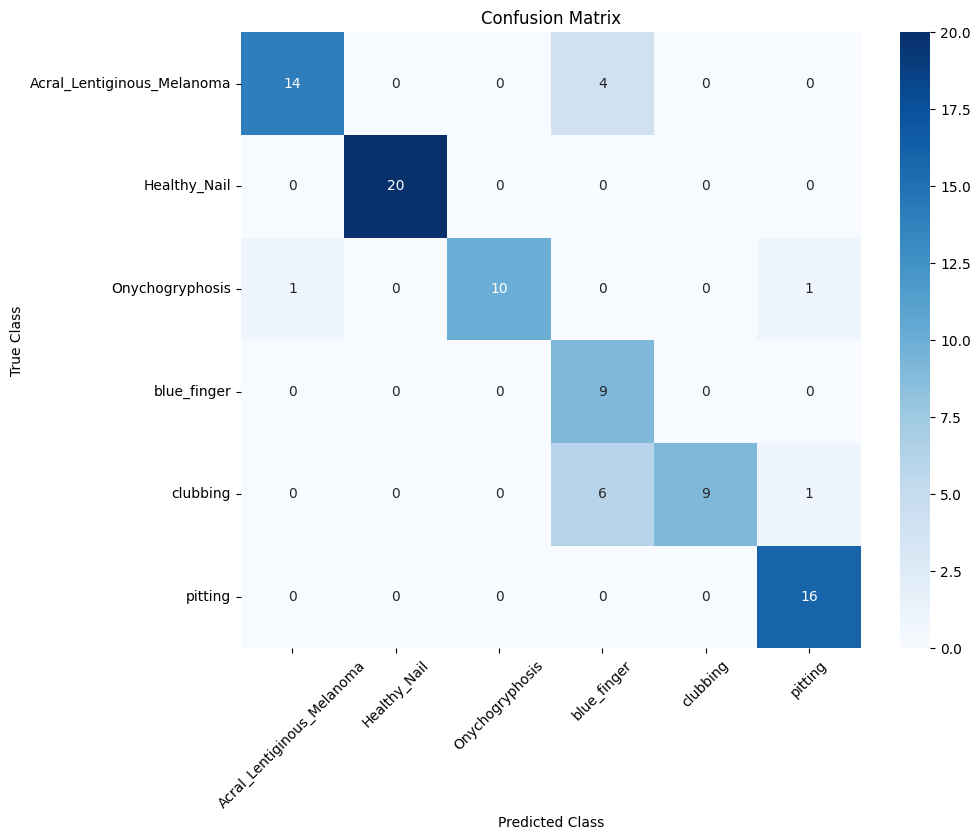

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.78      0.85        18
           1       1.00      1.00      1.00        20
           2       1.00      0.83      0.91        12
           3       0.47      1.00      0.64         9
           4       1.00      0.56      0.72        16
           5       0.89      1.00      0.94        16

    accuracy                           0.86        91
   macro avg       0.88      0.86      0.84        91
weighted avg       0.92      0.86      0.86        91



In [ ]:
Model.save("/content/drive/MyDrive/Computervison/nail_disease_model.h5")
print("Model tersimpan di Google Drive.")

Model tersimpan di Google Drive.


Saving Screen-Shot-2021-10-15-at-10-36-15-AM_png.rf.07fe9e00799550cf0f7834112b8b1a9d.jpg to Screen-Shot-2021-10-15-at-10-36-15-AM_png.rf.07fe9e00799550cf0f7834112b8b1a9d.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


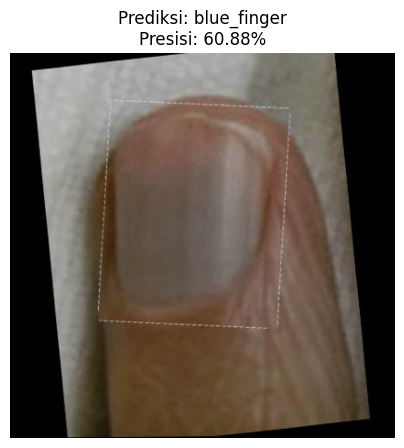


Probabilitas tiap kelas:
Acral_Lentiginous_Melanoma: 26.90%
Healthy_Nail: 0.64%
Onychogryphosis: 0.18%
blue_finger: 60.88%
clubbing: 3.71%
pitting: 7.69%


In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()

for fn in uploaded.keys():
    img_path = fn

    # load & preprocess gambar
    img = image.load_img(img_path, target_size=(260, 260))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    # prediksi
    pred = Model.predict(img_array)
    pred_class_idx = np.argmax(pred, axis=1)[0]
    pred_class = class_names[pred_class_idx]
    confidence = pred[0][pred_class_idx] * 100

    # tampilkan gambar + hasil prediksi
    plt.figure(figsize=(5,5))
    plt.imshow(image.load_img(img_path))
    plt.axis("off")
    plt.title(f"Prediksi: {pred_class}\nPresisi: {confidence:.2f}%")
    plt.show()

    # tampilkan semua probabilitas per kelas
    print("\nProbabilitas tiap kelas:")
    for i, cls in enumerate(class_names):
        print(f"{cls}: {pred[0][i]*100:.2f}%")

In [ ]:
# Simpan model ke Google Drive
Model.save("/content/drive/MyDrive/Computervison/nail_disease_model.h5")

# Simpan juga urutan label kelas (penting untuk web, biar prediksi tidak tertukar)
import json

class_indices = train.class_indices  # contoh: {'Acral_Lentiginous_Melanoma': 0, ...}
labels = {v: k for k, v in class_indices.items()}  # balik jadi {0: 'nama_kelas', ...}

with open("/content/drive/MyDrive/Computervison/labels.json", "w") as f:
    json.dump(labels, f)

print("✅ Model dan label tersimpan di Drive.")
print(labels)

✅ Model dan label tersimpan di Drive.
{0: 'Acral_Lentiginous_Melanoma', 1: 'Healthy_Nail', 2: 'Onychogryphosis', 3: 'blue_finger', 4: 'clubbing', 5: 'pitting'}
